In [1]:
import matplotlib.pyplot as plt
import sys

In [2]:
!{sys.executable} ../kbencoder.py --generate_kb --num_rules 400 --new_vocab --save_vocab

Classes: 1000000000.0
Max arity: 4
KB generated (400)


In [3]:
!{sys.executable} ../kbencoder.py --kb_path randomKB.txt --train_unification_model

Using cuda device
Uni model embed size: 50
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [████████------------] 29492/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [██████████████------] 50487/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [████████████████████] 70000/70000 Triplet encodings                                               
Early stopping triggered-------------] 18.4% Epoch | [Epoch 93/500, Training Loss: 0.2602, Validation Loss: 0.4997]
Saved model.
Saved plot.
unification model generated


In [4]:
import glob
glob.glob('training_loss*.png')

['training_loss-10-100-4-50.png']

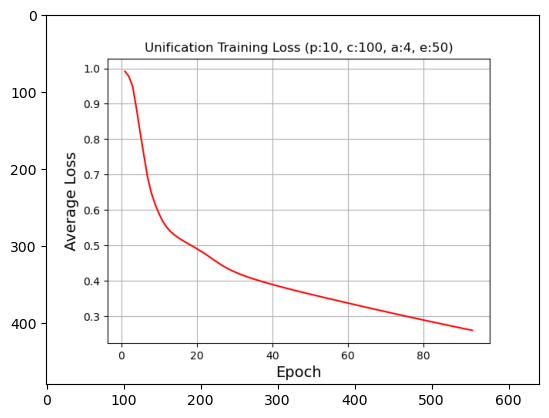

In [5]:
img = plt.imread('training_loss-10-100-4-50.png')
plt. imshow(img)

In [6]:
!{sys.executable} ../kbencoder.py --kb_path randomKB.txt -g

Generating facts list...
Forward chaining depth: 1
New facts: 126
Forward chaining depth: 2
New facts: 2
Forward chaining depth: 3

Facts list generated
128 total facts. Max depth = 2

Number of queries: 200
100 training queries generated
100 testing queries generated


In [7]:
!{sys.executable} ../kbencoder.py --kb_path randomKB.txt -p

running training queries...
Negative facts will be generated
1: [p2(X0), p6(a0, X0, a7, a79)]
min depth: 1                                                                                        
Nodes: 66699                                                                                        
Answers: 27                                                                                         

2: [p1(X2, a20)]
Restart...                                                                                          
min depth: 2                                                                                        
Nodes: 1818                                                                                         
Answers: 401                                                                                        

3: [p6(a71, a62, a25, X0), p2(X0), p9(a33, X0, X1), p9(X1, a10, a23)]
min depth: 1                                                                                        
Nodes: 2 

In [8]:
!{sys.executable} ../nnreasoner.py --embed_type unification

States from vocab: vocab
Num predicates: 10
Max arity: 4
Num constants: 100
Num variables: 10

Training unification
Embed size: 50
Reading examples from mr_train_examples.csv
Parsing examples...
Generating embeddings...
Embedding input size: 450
 [███████████████] 117367/117367 Prepping examples                                                  
Loaded data...
Using cuda device
0	0.32121 (-)
50	0.17676 (-0.0028)
100	0.16295 (-0.0015)
150	0.15182 (-0.0011)
200	0.14657 (-0.0008)
250	0.14133 (-0.0007)
300	0.13624 (-0.0006)
350	0.13033 (-0.0005)
400	0.12351 (-0.0004)
450	0.11762 (-0.0004)
500	0.11305 (-0.0004)
550	0.10739 (-0.0003)
600	0.10533 (-0.0003)
650	0.10160 (-0.0003)
700	0.09756 (-0.0003)
750	0.09626 (-0.0003)
800	0.09287 (-0.0002)
850	0.09180 (-0.0002)
900	0.08922 (-0.0002)
950	0.08776 (-0.0002)
1000	0.08587 (-0.0002)
1050	0.08358 (-0.0002)
1100	0.08180 (-0.0002)
1150	0.08211 (-0.0002)
1200	0.07951 (-0.0002)
1250	0.07950 (-0.0001)
1300	0.07930 (-0.0001)
1350	0.07837 (-0.0001)
1400	

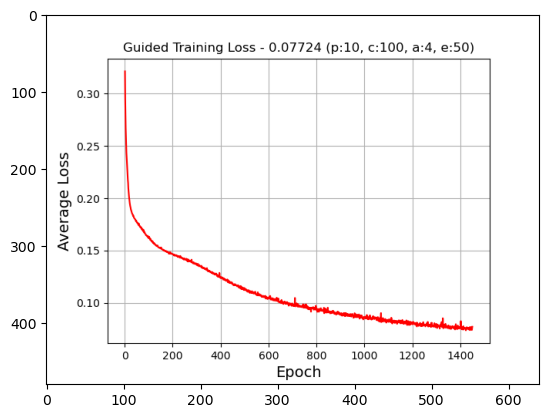

In [9]:
img = plt.imread('guided_loss-unification10-100-4-50.png')
plt. imshow(img)

In [10]:
!{sys.executable}  ../evaluate.py --kb randomKB.txt -s
!{sys.executable} ../evaluate.py --kb randomKB.txt -u

using cuda device
STANDARD

Query 1: [p6(X8, X7, a7, a79)]
20739 :: 4 - 00:00:00 (21950 nps)                                                                   

Query 2: [p9(a46, X7, X2)]
3 :: 2 - 00:00:00 (2504 nps)                                                                        

Query 3: [p6(a92, a15, X3, X5)]
6 :: 2 - 00:00:00 (1489 nps)                                                                        

Query 4: [p6(X1, X2, a90, X0), p3(X0, X0), p9(a23, X1, a51), p1(X1, a5), p0(X2, a9)]
7 :: 6 - 00:00:00 (3642 nps)                                                                        

Query 5: [p6(X3, a18, X9, a0)]
3 :: 2 - 00:00:00 (5778 nps)                                                                        

Query 6: [p0(a58, X0), p8(a94, X0)]
3 :: 2 - 00:00:00 (4139 nps)                                                                        

Query 7: [p6(X8, a0, X1, X2)]
2 :: 1 - 00:00:00 (3440 nps)                                                            

In [11]:
!ls *.csv

ming-10-100-4-50.csv  mr_train_examples.csv  std-10-100-4-50.csv  triplets.csv


In [12]:
!head std-10-100-4-50.csv 
!head ming-10-100-4-50.csv

query,std reasoner,std nodes explored,std min depth,success,time
1,std,20739,4,True,0.9448162959999991
2,std,3,2,True,0.001197616999998985
3,std,6,2,True,0.0040280870000000135
4,std,7,6,True,0.0019216719999999299
5,std,3,2,True,0.0005191910000004185
6,std,3,2,True,0.0007246379999994446
7,std,2,1,True,0.0005812379999987627
8,std,2,1,True,0.0005471410000001953
9,std,3,2,True,0.0010604839999999172
query,ming reasoner,ming nodes explored,ming min depth,success,time
1,ming,235,4,True,4.777145246
2,ming,3,2,True,0.035885076999999654
3,ming,3,2,True,0.005967354000000924
4,ming,128,6,True,1.3929632410000004
5,ming,3,2,True,0.003261538999998592
6,ming,3,2,True,0.011575369999999197
7,ming,2,1,True,0.00565855099999979
8,ming,2,1,True,0.004083488000000912
9,ming,3,2,True,0.036124792999999045
